In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

Sport csv

In [3]:
df = pd.read_csv("../../../../PYTHON-2-DATASET-main/DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [4]:
df["Weather"] = np.where(df["Weather"]=="Cloudy",0,np.where(df["Weather"]=="Rain",1,2))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,Hot,High,Weak,No
1,Day 2,2,Hot,High,Strong,No
2,Day 3,0,Hot,High,Weak,Yes
3,Day 4,1,Mild,High,Weak,Yes
4,Day 5,1,Cool,Normal,Weak,Yes
5,Day 6,1,Cool,Normal,Strong,No
6,Day 7,0,Cool,Normal,Strong,Yes
7,Day 8,2,Mild,High,Weak,No
8,Day 9,2,Cool,Normal,Weak,Yes
9,Day 10,1,Mild,Normal,Weak,Yes


In [5]:
df["Temperature"] = np.where(df["Temperature"]=="Cool",0,np.where(df["Temperature"]=="Hot",1,2))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,High,Weak,No
1,Day 2,2,1,High,Strong,No
2,Day 3,0,1,High,Weak,Yes
3,Day 4,1,2,High,Weak,Yes
4,Day 5,1,0,Normal,Weak,Yes
5,Day 6,1,0,Normal,Strong,No
6,Day 7,0,0,Normal,Strong,Yes
7,Day 8,2,2,High,Weak,No
8,Day 9,2,0,Normal,Weak,Yes
9,Day 10,1,2,Normal,Weak,Yes


In [6]:
df["Humidity"] = np.where(df["Humidity"]=="High",0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,Weak,No
1,Day 2,2,1,0,Strong,No
2,Day 3,0,1,0,Weak,Yes
3,Day 4,1,2,0,Weak,Yes
4,Day 5,1,0,1,Weak,Yes
5,Day 6,1,0,1,Strong,No
6,Day 7,0,0,1,Strong,Yes
7,Day 8,2,2,0,Weak,No
8,Day 9,2,0,1,Weak,Yes
9,Day 10,1,2,1,Weak,Yes


In [7]:
df["Wind"] = np.where(df["Wind"]=="Strong",0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,No
1,Day 2,2,1,0,0,No
2,Day 3,0,1,0,1,Yes
3,Day 4,1,2,0,1,Yes
4,Day 5,1,0,1,1,Yes
5,Day 6,1,0,1,0,No
6,Day 7,0,0,1,0,Yes
7,Day 8,2,2,0,1,No
8,Day 9,2,0,1,1,Yes
9,Day 10,1,2,1,1,Yes


In [8]:
df["Play_Sports?"] = np.where(df["Play_Sports?"]=="Yes",1,0)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [9]:
df.drop(columns=["Day"] ,inplace=True)

In [10]:
y = df["Play_Sports?"]
x = df.drop(columns=["Play_Sports?"])

In [11]:
dtree = DecisionTreeClassifier(criterion="entropy")
model = dtree.fit(x,y)
y_pred = model.predict(x)
y_pred  

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [12]:
diff = pd.DataFrame({'Actual':y,'Predicted':y_pred})
diff

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [13]:
print("accuracy",metrics.accuracy_score(y,y_pred))

accuracy 1.0


In [14]:
cm = metrics.confusion_matrix(y,y_pred)
cm

array([[5, 0],
       [0, 9]])

In [15]:
tr = tree.export_text(model)
print(tr)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



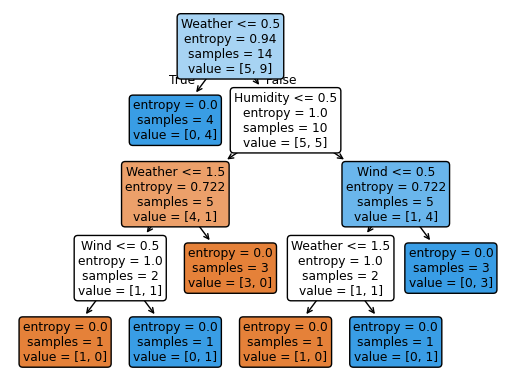

In [16]:
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)  
plt.show()

In [17]:
df.to_excel("1.xlsx")

CGPA dataset

In [18]:
df = pd.read_csv("../../../../PYTHON-2-DATASET-main/DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [19]:
y = df["Job Offered"]
x = df.drop(columns=["Job Offered"])

In [20]:
dtree = DecisionTreeClassifier(criterion="entropy")
model = dtree.fit(x,y)
y_pred = model.predict(x)
y_pred  

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [21]:
diff = pd.DataFrame({'Actual':y,'Predicted':y_pred})
diff

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [22]:
print("accuracy",metrics.accuracy_score(y,y_pred))

accuracy 1.0


In [23]:
cm = metrics.confusion_matrix(y,y_pred)
cm

array([[10,  0],
       [ 0,  8]])

In [24]:
tr = tree.export_text(model)
print(tr)

|--- feature_2 <= 0.50
|   |--- class: 0
|--- feature_2 >  0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- class: 0
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 1



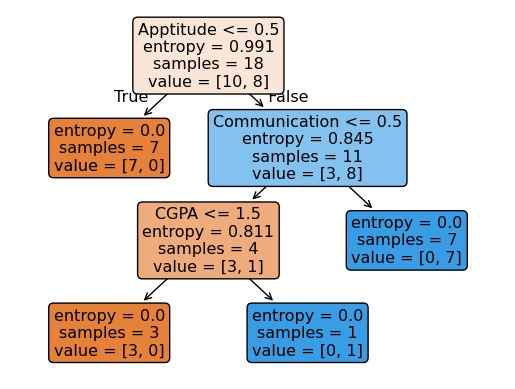

In [25]:
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)  
plt.show()

In [26]:
df = pd.read_csv("../../../../PYTHON-2-DATASET-main/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [27]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [30]:
x =df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y =df["Outcome"]

In [31]:
dtree = DecisionTreeClassifier(criterion="entropy")
model = dtree.fit(x,y)
y_pred = model.predict(x)
y_pred  

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [32]:
diff = pd.DataFrame({'Actual':y,'Predicted':y_pred})
diff

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
763,0,0
764,0,0
765,0,0
766,1,1


In [33]:
print("accuracy",metrics.accuracy_score(y,y_pred))

accuracy 1.0


In [34]:
cm = metrics.confusion_matrix(y,y_pred)
cm

array([[500,   0],
       [  0, 268]])

In [35]:
tr = tree.export_text(model)
print(tr)

|--- feature_1 <= 127.50
|   |--- feature_7 <= 28.50
|   |   |--- feature_5 <= 30.95
|   |   |   |--- feature_0 <= 7.50
|   |   |   |   |--- feature_6 <= 0.67
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_6 >  0.67
|   |   |   |   |   |--- feature_6 <= 0.69
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_6 >  0.69
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  7.50
|   |   |   |   |--- class: 1
|   |   |--- feature_5 >  30.95
|   |   |   |--- feature_2 <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- feature_2 >  37.00
|   |   |   |   |--- feature_6 <= 0.50
|   |   |   |   |   |--- feature_5 <= 45.35
|   |   |   |   |   |   |--- feature_6 <= 0.28
|   |   |   |   |   |   |   |--- feature_4 <= 89.00
|   |   |   |   |   |   |   |   |--- feature_2 <= 55.00
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- feature_2 >  55.00
|   |   |   |   |   |   |   |   |   |--- feature_6 <= 0.27
|   

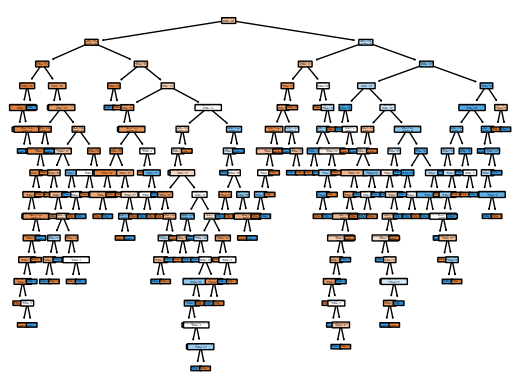

In [36]:
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)  
plt.show()

## Random Forest
